In [25]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Assume X and y are your features and target variable
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

X = df[['Age','Fare']]
y = df['Survived']

# see features
X

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


In [3]:
# see target
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [26]:
# check nan and remove it 
X['Age'].isna().sum()

177

In [27]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)

array = imputer.fit_transform(X)

In [ ]:
# check nan values
pd.DataFrame(
    data= array,
    columns= X.columns
)['Age'].isna().sum()

0

In [31]:
X = pd.DataFrame(
    data= array,
    columns= X.columns
)

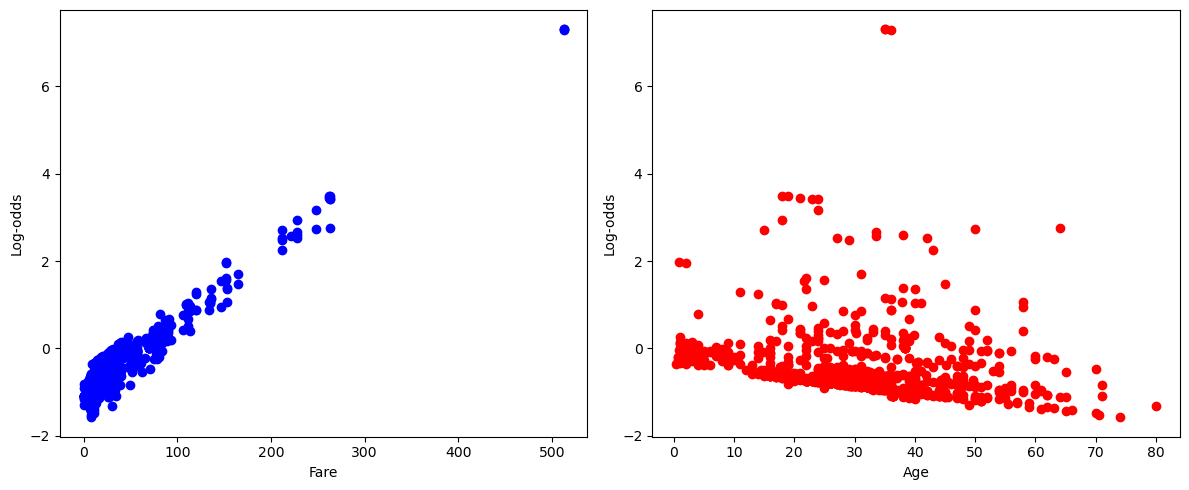

In [32]:
model = LogisticRegression()

# Fit the model on the data
model.fit(X, y)

# Get predictions (probabilities)
predicted = model.predict_proba(X)[:,1]

# Getting log odds values
log_odds = np.log(predicted / (1 - predicted))

# Create figure and axes for subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot Fare vs log-odds
ax[0].scatter(x=X['Fare'].values, y=log_odds, color='blue')
ax[0].set_xlabel("Fare")
ax[0].set_ylabel("Log-odds")

# Plot Age vs log-odds
ax[1].scatter(x=X['Age'].values, y=log_odds, color='red')
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Log-odds")

# Show plots
plt.tight_layout()
plt.show()


fare ka sath linear realtionship ha             
lakin age ka sath thoda linear realtionship kam ha 

# polynomial logistic regresic 

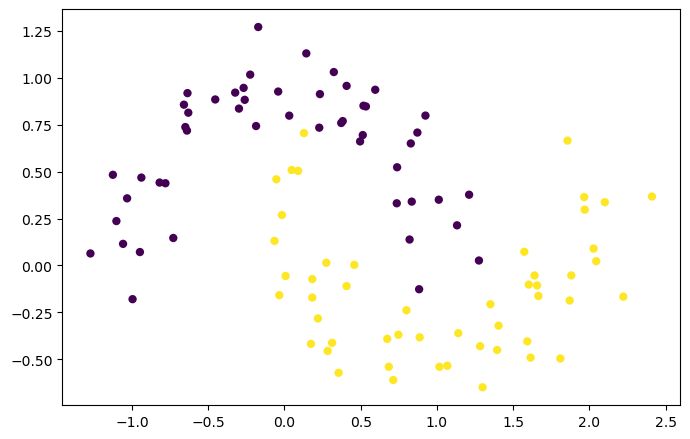

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 1. Generate the half-circles / moons dataset
# n_samples: total number of points
# noise: standard deviation of Gaussian noise added to the data
# random_state: ensures reproducibility to get the exact same pattern
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

# 2. Recreate the scatter plot
plt.figure(figsize=(7, 4.5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='none')

# Adjust layout to match your image style
plt.tight_layout()
plt.show()


In [8]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

clf.fit(X,y)

LogisticRegression()

## linear logistic regresion 

<Axes: >

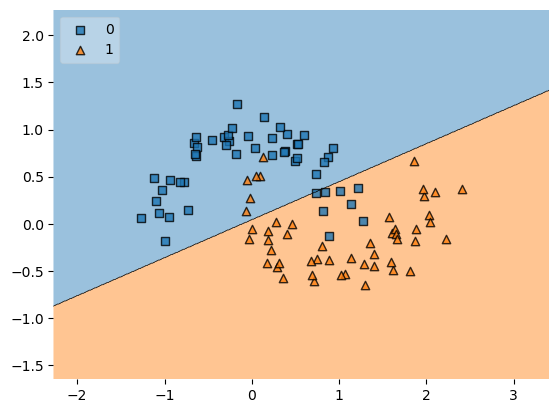

In [9]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X,y.astype('int'),clf,legend = 2)

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(
    clf, # clasfifer our logisitc model
    X,y, # features and target
    scoring='accuracy', # classfication metric
    cv = 10 # how many kfolds we need
)

array([0.9, 0.7, 1. , 1. , 0.9, 0.8, 0.9, 0.9, 0.8, 0.8])

In [13]:
np.mean(cross_val_score(
    clf,
    X,y,
    scoring='accuracy',
    cv = 10
))

0.8699999999999999

In [14]:
from sklearn.preprocessing import PolynomialFeatures
polynomial_model = PolynomialFeatures(degree = 3,include_bias=False)
X_transform = polynomial_model.fit_transform(X)

In [17]:
# now again train logistic regresion model on it
clf1 = LogisticRegression()
cross_val_score(
    clf1,
    X_transform,y,
    scoring='accuracy',
    cv = 10
)

array([0.9, 0.9, 1. , 1. , 0.9, 0.8, 0.9, 1. , 0.9, 0.8])

In [ ]:
np.mean(cross_val_score(
    clf1,
    X_transform,y,
    scoring='accuracy',
    cv = 10
))
# wow accuracy increase 

0.9100000000000001

In [37]:
# import ipywidgets as widgets
# widgets.interact(polynomial_plot_decision_boundary ,degree= (1,10,1))

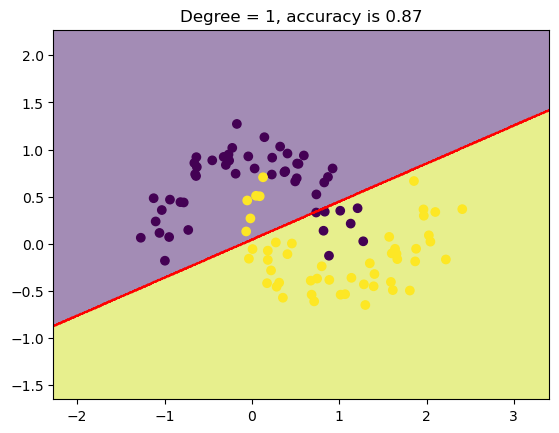

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

def polynomial_plot_decision_boundary(X, y, degree=1, boundary_color='k'):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    clf = LogisticRegression()
    clf.fit(X_trf, y)
    
    accuracy = np.mean(cross_val_score(clf, X_trf, y, scoring='accuracy', cv=10))
    
    a = np.arange(start=X[:, 0].min() - 1, stop=X[:, 0].max() + 1, step=0.01)
    b = np.arange(start=X[:, 1].min() - 1, stop=X[:, 1].max() + 1, step=0.01)

    XX, YY = np.meshgrid(a, b)
    
    input_array = np.array([XX.ravel(), YY.ravel()]).T

    labels = clf.predict(poly.transform(input_array))
    
    # Plot filled decision regions
    plt.contourf(XX, YY, labels.reshape(XX.shape), alpha=0.5)
    
    # Plot the explicit decision boundary line with custom color
    plt.contour(XX, YY, labels.reshape(XX.shape), colors=[boundary_color], linewidths=1)
    
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree, np.round(accuracy, 4)))

# Example usage:
polynomial_plot_decision_boundary(X, y, degree=1, boundary_color='red')

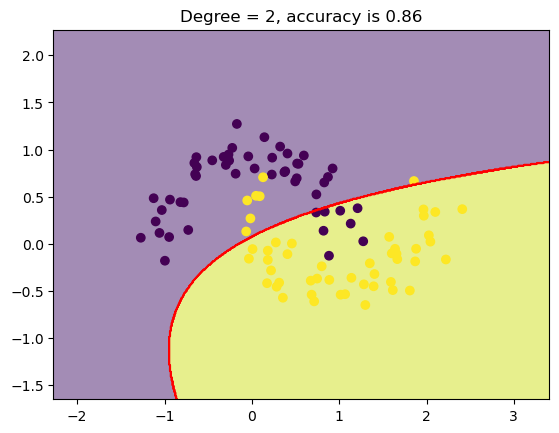

In [45]:
# try with degree 2
polynomial_plot_decision_boundary(X, y, degree=2, boundary_color='red')

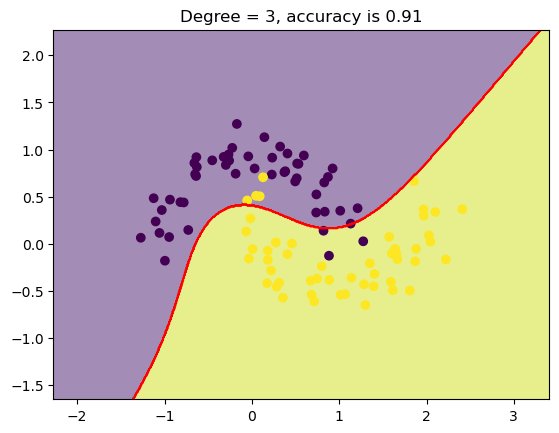

In [46]:
# try with degree 3
# try with degree 2
polynomial_plot_decision_boundary(X, y, degree=3, boundary_color='red')

In [ ]:
import ipywidgets as widgets

widgets.interact(
    lambda degree: polynomial_plot_decision_boundary(X, y, degree,boundary_color='red'), 
    degree=(1, 10, 1)
)

interactive(children=(IntSlider(value=5, description='degree', max=10, min=1), Output()), _dom_classes=('widge…

<function __main__.<lambda>(degree)>

Bias Varience Traedoff or               
Mean Varience Traefoff

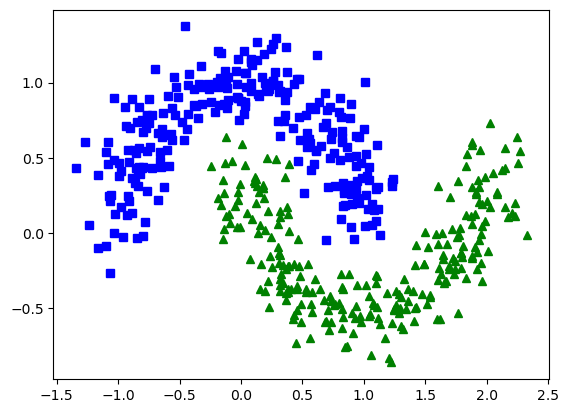

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split

# Create a synthetic dataset
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")


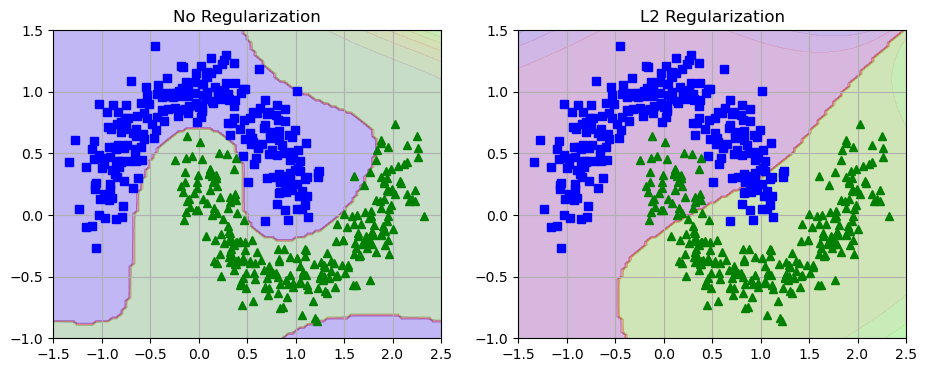

In [2]:
# Create a function to plot the dataset
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True, which='both')

# Create a function to plot the decision boundary
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

# Logistic Regression without regularization
model_no_reg = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("std_scaler", StandardScaler()),
    ("log_reg", LogisticRegression(C=1e10, solver="liblinear", random_state=42))
])

# Logistic Regression with L2 regularization
model_l2 = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("std_scaler", StandardScaler()),
    ("log_reg", LogisticRegression(C=0.001, solver="liblinear", random_state=42))  # C=0.1 implies a stronger regularization
])

model_no_reg.fit(X_train, y_train)
model_l2.fit(X_train, y_train)

# Now, let's plot the decision boundaries
plt.figure(figsize=(11, 4))

plt.subplot(121)
plot_predictions(model_no_reg, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title("No Regularization")

plt.subplot(122)
plot_predictions(model_l2, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title("L2 Regularization")

plt.show()
